# Paired Policy Evaluation Analysis

This notebook loads paired evaluation outputs (`paired_eval_summary.json`, `paired_eval_rollouts.csv`, `paired_deltas.csv`) and generates compact tables and plots for debugging residual policy behavior.

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except Exception:
    sns = None

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

In [2]:
def find_results_dir():
    cwd = Path.cwd()
    candidates = [
        cwd / 'output' / 'paired_eval_results',
        cwd / 'notebooks' / 'paired_eval_results',
        cwd.parent / 'output' / 'paired_eval_results',
    ]
    for path in candidates:
        if (path / 'paired_eval_summary.json').exists():
            return path
    raise FileNotFoundError('Could not find paired_eval_results in expected locations.')

results_dir = find_results_dir()
summary_path = results_dir / 'paired_eval_summary.json'
rollouts_path = results_dir / 'paired_eval_rollouts.csv'
deltas_path = results_dir / 'paired_deltas.csv'

print(f'Results directory: {results_dir}')
summary = json.loads(summary_path.read_text())
rollouts_df = pd.read_csv(rollouts_path)
deltas_df = pd.read_csv(deltas_path)

Results directory: /home/griffing52/vail/bot2bot/bot2bot/a2l/a2l-pr/output/paired_eval_results


In [3]:
summary_df = pd.DataFrame(summary.get('summaries', []))
paired_df = pd.DataFrame(summary.get('paired', []))

display(summary_df)
display(paired_df)
display(rollouts_df.head(20))

,policy,checkpoint,n_rollouts,mean_return,std_return,success_rate,video_path,mean_interventions,mean_gate,max_gate
0,bc,/home/griffing52/vail/bot2bot/bot2bot/a2l/robo...,50,0.44,0.496387,0.44,None,NaN,NaN,NaN
1,bc_gated_residual,/home/griffing52/vail/bot2bot/bot2bot/a2l/robo...,50,0.46,0.498397,0.46,None,12.96,0.327554,0.968896
2,diffusion,/home/griffing52/vail/bot2bot/bot2bot/a2l/robo...,50,0.82,0.384187,0.82,None,NaN,NaN,NaN
3,diffusion_gated_residual,/home/griffing52/vail/bot2bot/bot2bot/a2l/robo...,50,0.80,0.400000,0.80,None,14.84,0.337188,0.581213


,policy_a,policy_b,mean_return_a,mean_return_b,mean_delta,std_delta,fraction_b_better,fraction_tied
0,bc,bc_gated_residual,0.44,0.46,0.02,0.244131,0.04,0.94
1,diffusion,diffusion_gated_residual,0.82,0.80,-0.02,0.468615,0.10,0.78


,had_intervention,horizon,initial_state,interventions,max_gate,mean_gate,mean_residual_norm,policy,return,success,top_failure_at_max_gate,top_failure_confidence
0,NaN,400,0,NaN,NaN,NaN,NaN,bc,0.0,0.0,NaN,NaN
1,NaN,400,1,NaN,NaN,NaN,NaN,bc,0.0,0.0,NaN,NaN
2,NaN,242,2,NaN,NaN,NaN,NaN,bc,1.0,1.0,NaN,NaN
3,NaN,238,3,NaN,NaN,NaN,NaN,bc,1.0,1.0,NaN,NaN
4,NaN,400,4,NaN,NaN,NaN,NaN,bc,0.0,0.0,NaN,NaN
5,NaN,231,5,NaN,NaN,NaN,NaN,bc,1.0,1.0,NaN,NaN
6,NaN,400,6,NaN,NaN,NaN,NaN,bc,0.0,0.0,NaN,NaN
7,NaN,400,7,NaN,NaN,NaN,NaN,bc,0.0,0.0,NaN,NaN
8,NaN,400,8,NaN,NaN,NaN,NaN,bc,0.0,0.0,NaN,NaN
9,NaN,400,9,NaN,NaN,NaN,NaN,bc,0.0,0.0,NaN,NaN


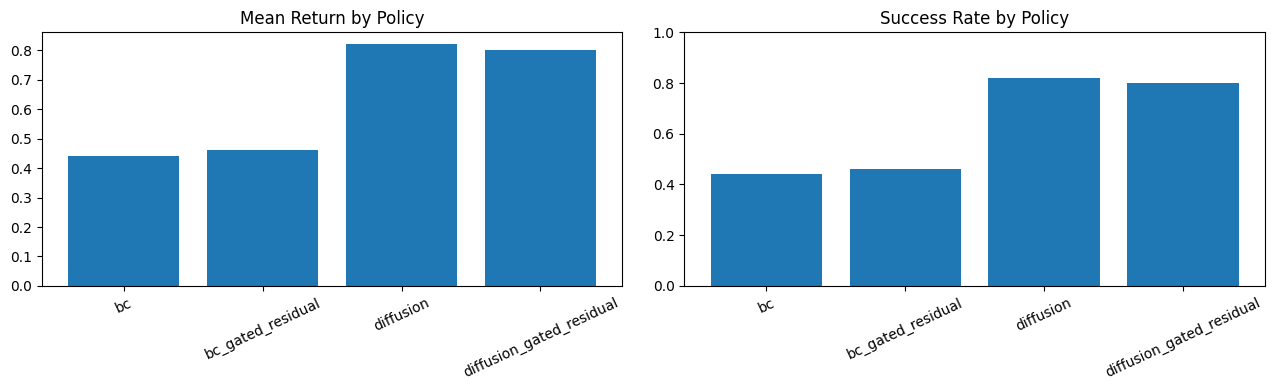

In [4]:
if not summary_df.empty:
    metrics = summary_df[['policy', 'mean_return', 'success_rate']].copy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].bar(metrics['policy'], metrics['mean_return'])
    axes[0].set_title('Mean Return by Policy')
    axes[0].tick_params(axis='x', rotation=25)

    axes[1].bar(metrics['policy'], metrics['success_rate'])
    axes[1].set_ylim(0, 1)
    axes[1].set_title('Success Rate by Policy')
    axes[1].tick_params(axis='x', rotation=25)

    plt.tight_layout()
    plt.show()
else:
    print('No policy summary rows found.')

,count,mean,std,min,25%,50%,75%,max
pair,,,,,,,,
bc_gated_residual - bc,50.0,0.02,0.246610,-1.0,0.0,0.0,0.0,1.0
diffusion_gated_residual - diffusion,50.0,-0.02,0.473373,-1.0,0.0,0.0,0.0,1.0


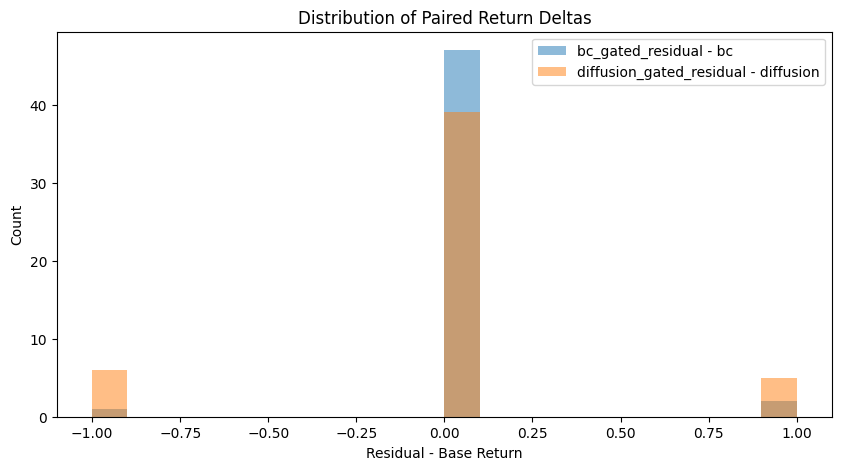

In [5]:
if not deltas_df.empty:
    paired_return_cols = [c for c in deltas_df.columns if c.endswith('_return')]
    delta_rows = []

    for col in paired_return_cols:
        if col.startswith('bc_gated_residual_') and 'bc_return' in deltas_df.columns:
            d = deltas_df[col] - deltas_df['bc_return']
            delta_rows.append(pd.DataFrame({'pair': 'bc_gated_residual - bc', 'delta': d}))
        if col.startswith('diffusion_gated_residual_') and 'diffusion_return' in deltas_df.columns:
            d = deltas_df[col] - deltas_df['diffusion_return']
            delta_rows.append(pd.DataFrame({'pair': 'diffusion_gated_residual - diffusion', 'delta': d}))

    if delta_rows:
        all_deltas = pd.concat(delta_rows, ignore_index=True).dropna()
        display(all_deltas.groupby('pair')['delta'].describe())

        if sns is not None:
            sns.histplot(data=all_deltas, x='delta', hue='pair', bins=20, kde=True)
        else:
            for pair_name, g in all_deltas.groupby('pair'):
                plt.hist(g['delta'], bins=20, alpha=0.5, label=pair_name)
            plt.legend()
        plt.title('Distribution of Paired Return Deltas')
        plt.xlabel('Residual - Base Return')
        plt.ylabel('Count')
        plt.show()
    else:
        print('No paired delta columns matched expected naming.')
else:
    print('paired_deltas.csv is empty.')

Residual intervention metrics:


,policy,initial_state,interventions,mean_gate,max_gate,top_failure_at_max_gate,top_failure_confidence
50,bc_gated_residual,0,12.0,0.267191,0.532259,lateral_drift,0.277133
51,bc_gated_residual,1,0.0,0.349852,0.404463,no_failure,0.655093
52,bc_gated_residual,2,0.0,0.317992,0.448554,no_failure,0.566656
53,bc_gated_residual,3,0.0,0.260895,0.413259,no_failure,0.596793
54,bc_gated_residual,4,0.0,0.207127,0.395632,no_failure,0.620818
...,...,...,...,...,...,...,...
195,diffusion_gated_residual,45,0.0,0.324446,0.453364,no_failure,0.558087
196,diffusion_gated_residual,46,21.0,0.352164,0.520222,lateral_drift,0.280420
197,diffusion_gated_residual,47,15.0,0.334695,0.541206,lateral_drift,0.267374
198,diffusion_gated_residual,48,26.0,0.352544,0.539700,lateral_drift,0.279719


,count
top_failure_at_max_gate,
lateral_drift,54
no_failure,43
premature_gripper_close,3


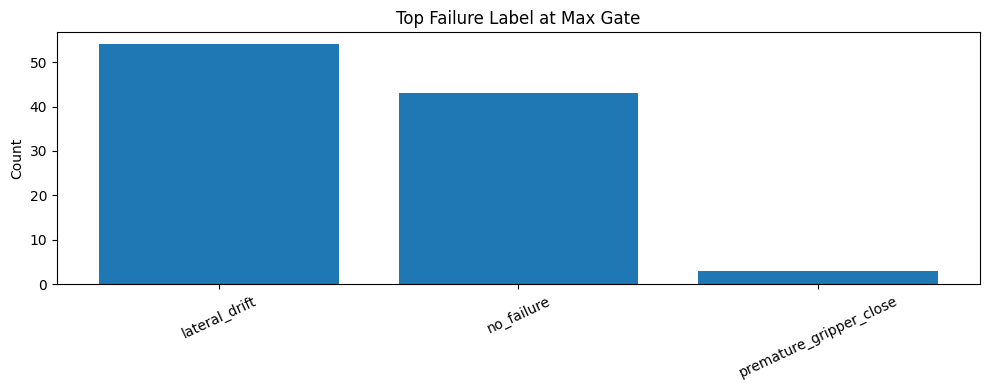

In [6]:
residual_rows = rollouts_df[rollouts_df['policy'].astype(str).str.contains('gated_residual', na=False)].copy()
if residual_rows.empty:
    print('No residual rollout rows found.')
else:
    for col in ['interventions', 'mean_gate', 'max_gate', 'top_failure_confidence']:
        if col in residual_rows.columns:
            residual_rows[col] = pd.to_numeric(residual_rows[col], errors='coerce')

    print('Residual intervention metrics:')
    display(residual_rows[['policy', 'initial_state', 'interventions', 'mean_gate', 'max_gate', 'top_failure_at_max_gate', 'top_failure_confidence']])

    if 'top_failure_at_max_gate' in residual_rows.columns:
        label_counts = residual_rows['top_failure_at_max_gate'].fillna('unknown').value_counts()
        display(label_counts.to_frame('count'))

        plt.figure(figsize=(10, 4))
        plt.bar(label_counts.index.astype(str), label_counts.values)
        plt.title('Top Failure Label at Max Gate')
        plt.ylabel('Count')
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.show()

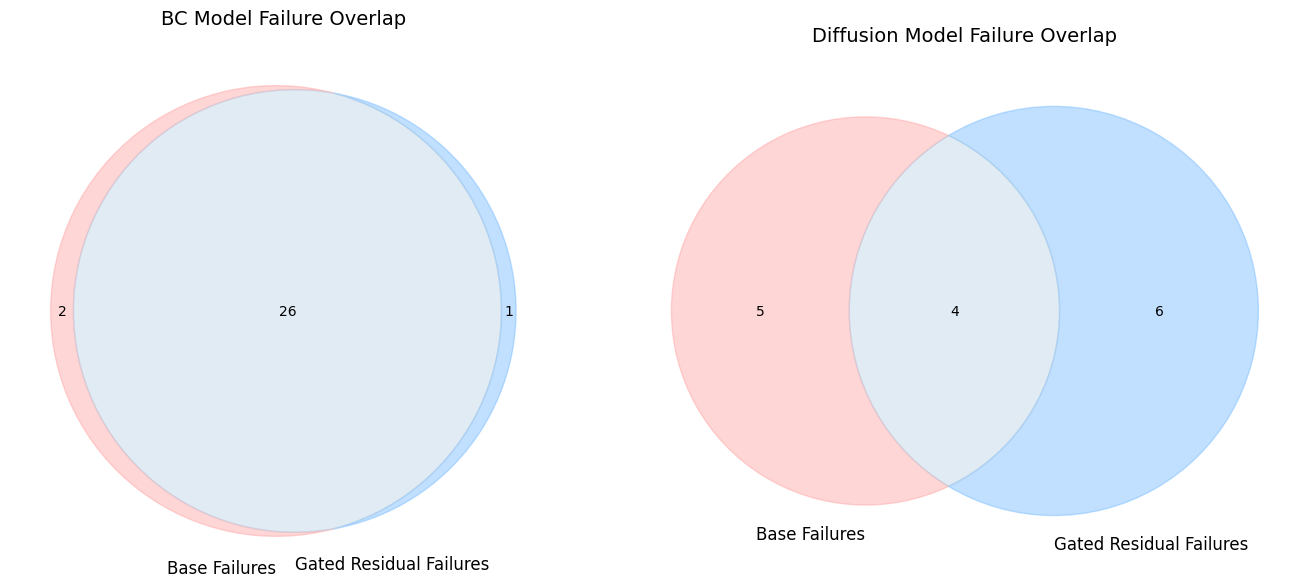

In [9]:
# 1. Install dependency if needed
# !pip install matplotlib-venn

from matplotlib_venn import venn2

# 2. Consolidate rows by 'initial_state' to pair up data properly
grouped_df = deltas_df.groupby('initial_state').first().reset_index()

# 3. Set up a side-by-side subplot canvas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns_colors = sns.color_palette("Pastel1", 2) if sns else ["#ff9999", "#66b3ff"]

# --- Model 1: Behavior Cloning (BC) ---
bc_base_fails = set(grouped_df[grouped_df['bc_success'] == 0.0]['initial_state'])
bc_resid_fails = set(grouped_df[grouped_df['bc_gated_residual_success'] == 0.0]['initial_state'])

venn_bc = venn2(
    subsets=[bc_base_fails, bc_resid_fails],
    set_labels=('Base Failures', 'Gated Residual Failures'),
    ax=axes[0]
)
axes[0].set_title("BC Model Failure Overlap", fontsize=14, pad=15)

# --- Model 2: Diffusion ---
diff_base_fails = set(grouped_df[grouped_df['diffusion_success'] == 0.0]['initial_state'])
diff_resid_fails = set(grouped_df[grouped_df['diffusion_gated_residual_success'] == 0.0]['initial_state'])

venn_diff = venn2(
    subsets=[diff_base_fails, diff_resid_fails],
    set_labels=('Base Failures', 'Gated Residual Failures'),
    ax=axes[1]
)
axes[1].set_title("Diffusion Model Failure Overlap", fontsize=14, pad=15)

# 4. Apply custom colors to both plots cleanly
for venn in [venn_bc, venn_diff]:
    if venn:
        if venn.get_patch_by_id('10'): venn.get_patch_by_id('10').set_color(sns_colors[0])
        if venn.get_patch_by_id('01'): venn.get_patch_by_id('01').set_color(sns_colors[1])
        if venn.get_patch_by_id('11'): venn.get_patch_by_id('11').set_color("#b3cde3") # soft purple mix

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import json

eval_results = Path("/home/griffing52/vail/bot2bot/bot2bot/a2l/a2l-pr/output/official_eval_results")

vals = []

for experiment in eval_results.iterdir():
    if experiment.is_dir(): 
        name = experiment.name
        with open(experiment / "official_eval_summary.json") as f:
            summary = json.load(f)
            print(f"Experiment: {name}")
            for policy_summary in summary.get("summaries", []):
                policy_name = policy_summary.get("policy", "unknown")
                mean_return = policy_summary.get("mean_return", "N/A")
                success_rate = policy_summary.get("success_rate", "N/A")
                mean_interventions = policy_summary.get("mean_interventions", "N/A")
                mean_gate = policy_summary.get("mean_gate", "N/A")
                max_gate = policy_summary.get("max_gate", "N/A")
                vals.append({
                    "experiment": name,
                    "policy": policy_name,
                    "mean_return": mean_return,
                    "success_rate": success_rate,
                    "mean_interventions": mean_interventions,
                    "mean_gate": mean_gate,
                    "max_gate": max_gate
                })

Experiment: gate_threshold_0.45
Experiment: gate_threshold_0.60
Experiment: gate_threshold_0.50
Experiment: gate_threshold_0.40
Experiment: gate_threshold_0.30
Experiment: gate_threshold_0.85
Experiment: gate_threshold_0.15
Experiment: gate_threshold_0.95
Experiment: gate_threshold_0.10
Experiment: gate_threshold_0.80
Experiment: gate_threshold_0.65
Experiment: gate_threshold_1.00
Experiment: gate_threshold_0.55
Experiment: gate_threshold_0.25
Experiment: gate_threshold_0.70
Experiment: gate_threshold_0.05
Experiment: gate_threshold_0.75
Experiment: gate_threshold_0.20
Experiment: gate_threshold_0.35
Experiment: gate_threshold_0.00
Experiment: gate_threshold_0.90


In [4]:
vals_df = pd.DataFrame(vals)
display(vals_df)

,experiment,policy,mean_return,success_rate,mean_interventions,mean_gate,max_gate
0,gate_threshold_0.45,bc,0.50,0.50,N/A,N/A,N/A
1,gate_threshold_0.45,bc_gated_residual,0.65,0.65,34.65,0.336421,0.928893
2,gate_threshold_0.45,diffusion,0.95,0.95,N/A,N/A,N/A
3,gate_threshold_0.45,diffusion_gated_residual,0.80,0.80,28.95,0.339571,0.648977
4,gate_threshold_0.60,bc,0.50,0.50,N/A,N/A,N/A
...,...,...,...,...,...,...,...
79,gate_threshold_0.00,diffusion_gated_residual,0.75,0.75,192.75,0.329543,0.641152
80,gate_threshold_0.90,bc,0.50,0.50,N/A,N/A,N/A
81,gate_threshold_0.90,bc_gated_residual,0.50,0.50,1.8,0.337388,0.980738
82,gate_threshold_0.90,diffusion,0.85,0.85,N/A,N/A,N/A


In [5]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Extract numeric threshold from experiment column
# vals_df["gate_threshold"] = (
#     vals_df["experiment"]
#     .str.extract(r'(\d+\.\d+)')
#     .astype(float)
# )

# # Sort thresholds
# vals_df = vals_df.sort_values("gate_threshold")

# # Plot
# plt.figure(figsize=(12, 6))

# sns.barplot(
#     data=vals_df,
#     x="gate_threshold",
#     y="success_rate",
#     hue="policy"
# )

# plt.xlabel("Gate Threshold")
# plt.ylabel("Success Rate")
# plt.title("Success Rate by Policy Across Gate Thresholds")
# plt.ylim(0, 1)

# plt.legend(title="Policy")
# plt.tight_layout()
# plt.show()

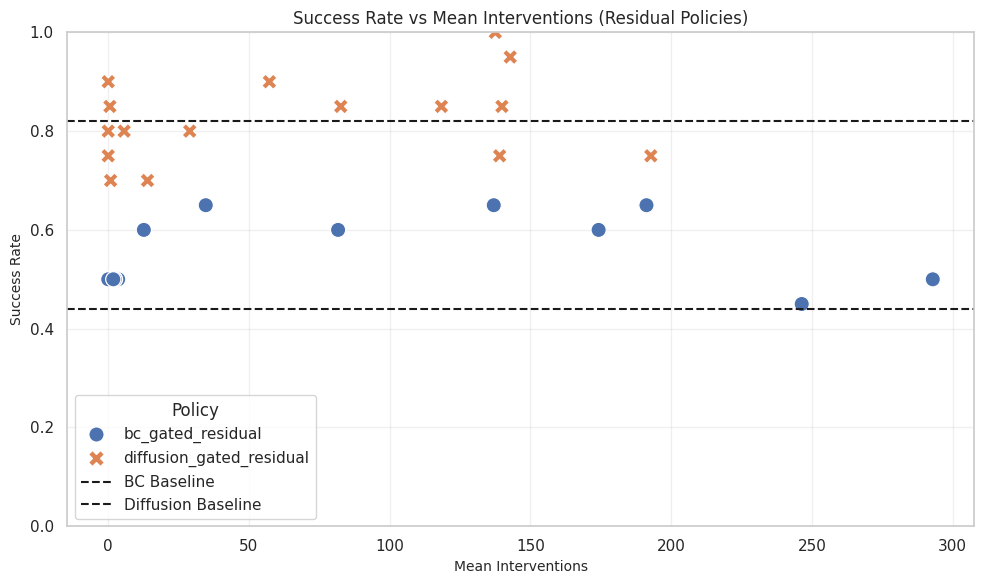

In [6]:
# Keep only residual policies
residual_df = vals_df[
    vals_df["policy"].str.contains("residual")
].copy()

# Optional: extract threshold for coloring / labeling
residual_df["gate_threshold"] = (
    residual_df["experiment"]
    .str.extract(r'(\d+\.\d+)')
    .astype(float)
)

# Scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=residual_df,
    x="mean_interventions",
    y="success_rate",
    hue="policy",              # color by policy
    style="policy",            # different marker shapes
    s=120
)

plt.axhline(y=0.44, color='k', linestyle='--', label='BC Baseline')
plt.axhline(y=0.82, color='k', linestyle='--', label='Diffusion Baseline')

plt.xlabel("Mean Interventions")
plt.ylabel("Success Rate")
plt.title("Success Rate vs Mean Interventions (Residual Policies)")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

plt.legend(title="Policy")
plt.tight_layout()
plt.show()

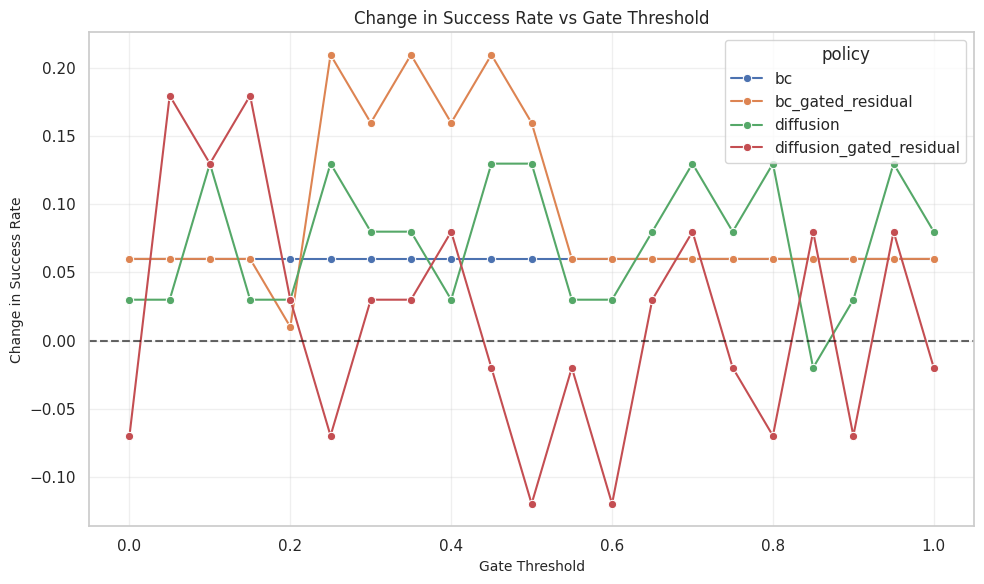

In [7]:
bc_baseline = 0.44
diffusion_baseline = 0.82

# Copy dataframe
delta_df = vals_df.copy()

# Extract numeric threshold
delta_df["gate_threshold"] = (
    delta_df["experiment"]
    .str.extract(r'(\d+\.\d+)')
    .astype(float)
)

# Compute change in success rate relative to baseline
def compute_delta(row):
    if "bc" in row["policy"]:
        return row["success_rate"] - bc_baseline
    elif "diffusion" in row["policy"]:
        return row["success_rate"] - diffusion_baseline
    return None

delta_df["success_rate_change"] = delta_df.apply(compute_delta, axis=1)

# Plot
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=delta_df,
    x="gate_threshold",
    y="success_rate_change",
    hue="policy",
    marker="o"
)

plt.axhline(0, color="black", linestyle="--", alpha=0.6)

plt.xlabel("Gate Threshold")
plt.ylabel("Change in Success Rate")
plt.title("Change in Success Rate vs Gate Threshold")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Notes
- If all labels remain `no_failure`, check whether the residual model was trained with mostly no-failure examples or if the intervention gate threshold is too low/high.
- To compare specific rollout twins with visual evidence, inspect videos in `output/paired_eval_results/videos`.